In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

# Distance-to-goal remapping

In [3]:
import numpy as np
from GridMaze.analysis.core import get_clusters as gc
from GridMaze.analysis.unit_match import get_across_maze_matches as mm
from GridMaze.analysis.unit_match import distance_to_goal as um_dtg

In [4]:
# get matches like this
matched_clusters = mm.get_cross_maze_matches(
    subject_ID="m2",
    maze_pair=("maze_1", "maze_2"),
    single_units=True,
    tuning_metric="distance_to_goal",
    min_split_half_corr=0.3,  # only keep matches that a both distance tuned to start with
    return_as="cluster_objects",
    verbose=True,
)

Found 260 matches for m2, maze_1.maze_2, with the given criteria.


In [5]:
# I've selected a few matched clusters from the above list that we can have a look at ...
_matched_clusters = np.array(
    [
        ["m2.2022-07-05.maze_cluster64", "m2.2022-07-11.maze_cluster49"],  # Maze_1, Maze_2
        ["m2.2022-07-03.maze_cluster90", "m2.2022-07-11.maze_cluster94"],
        ["m2.2022-07-05.maze_cluster28", "m2.2022-07-11.maze_cluster26"],
        ["m2.2022-07-04.maze_cluster86", "m2.2022-07-12.maze_cluster84"],
        ["m2.2022-07-05.maze_cluster44", "m2.2022-07-13.maze_cluster65"],
        ["m2.2022-07-02.maze_cluster87", "m2.2022-07-09.maze_cluster91"],
    ]
)

matched_clusters = np.array([[gc.get_cluster(C) for C in pair] for pair in _matched_clusters])

Text(0, 0.5, 'Firing Rate (Hz)')

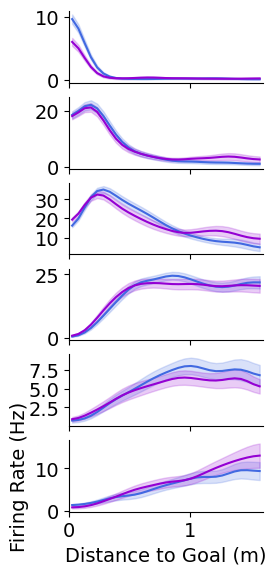

In [6]:
# set up fig for plotting matched clusters
f, axes = plt.subplots(6, 1, figsize=(2.5, 6.5), sharex=True)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

# plot matched cluster tuning curves on the same axis :)
for ax, pair in zip(axes, matched_clusters):
    for Clust, color in zip(pair, ["royalblue", "darkviolet"]):
        Clust.plot_tuning(
            feature="distance_to_goal",
            ax=ax,
            feature_kwargs={"color": color, "smooth_SD": 2},
        )
        ax.set_xlabel("")
        ax.set_ylabel("")
axes[-1].set_xlabel("Distance to Goal (m)")
axes[-1].set_ylabel("Firing Rate (Hz)")
# f.savefig("../results/distance_to_goal/figures/main/example_matched_clusters.pdf")

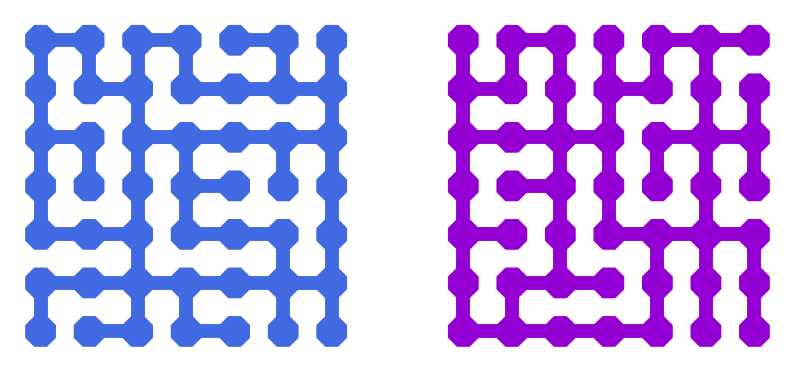

In [7]:
# plot coloured maze silhouttes to make plot legend
from GridMaze.maze import representations as mr
from GridMaze.maze import plotting as mp

f, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, maze_name, color in zip(axes, ["maze_1", "maze_2"], ["royalblue", "darkviolet"]):
    simple_maze = mr.get_simple_maze(maze_name)
    mp.plot_simple_maze_silhouette(simple_maze, ax, color)
# f.savefig("../results/distance_to_goal/figures/main/maze_silhouettes_legend.pdf")

In [8]:
from GridMaze.analysis.core import unit_matching as um

In [9]:
# lets convience ourselves that we are getting some good matched with UnitMatch
# reload(um)
# for i, pair in enumerate(matched_clusters):
#     save_path = f"../results/distance_to_goal/figures/supp/um_reports/{pair[0].cluster_unique_ID}X{pair[1].cluster_unique_ID}.pdf"
#     um.get_pairwise_report(pair[0], pair[1], save=True, save_path=save_path)

In [10]:
reload(um_dtg)
matched_tuning_dfs = um_dtg.get_matched_distance_tuning_dfs(verbose=False)

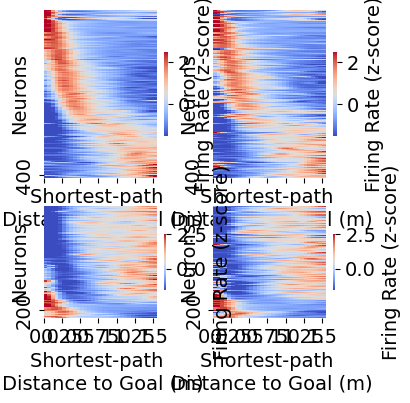

In [11]:
f, axes = plt.subplots(2, 2, figsize=(4, 4), height_ratios=[1.5, 1], sharex=True)
um_dtg.plot_matched_distance_tuning_heatmaps(*matched_tuning_dfs, min_corr=0.15, v_range=(-1.5, 2.5), axes=axes)
# f.savefig("../results/distance_to_goal/figures/supp/matched_distance_tuning_heatmaps.pdf")

Subject p-values:
   p_value
m2     0.0
m3     0.0
m4     0.0
m6     0.0
m7     0.0
m8     0.0
Random effects t-statistic: 6.549, p-value: 0.001
Subject p-values:
   p_value
m2     0.0
m3     0.0
m4   0.393
m6     0.0
m7     0.0
m8   0.021
Random effects t-statistic: 4.740, p-value: 0.005


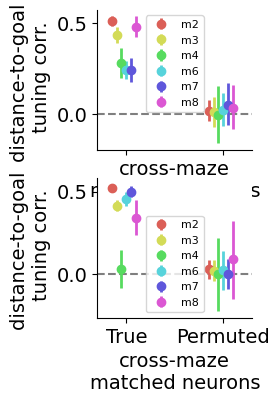

In [12]:
f, axes = plt.subplots(2, 1, figsize=(2, 4), sharex=True)
maze_pairs = [("maze_1", "maze_2"), ("maze_2", "rooms_maze")]
for maze_pair, ax in zip(maze_pairs, axes):
    results = um_dtg.get_cross_maze_corr_summary(maze_pair, verbose=False)
    um_dtg.plot_cross_maze_corrs_summary(results, print_stats=True, ax=ax)
# note m4 maze_2-rooms_maze has ~8 matched clusters so will exclude for final plot
# f.savefig("../results/distance_to_goal/figures/supp/cross_maze_match_corrs.pdf")